# GCAP3226 Week 4 — In-class exercise (5%)

**Individual.** Three tasks + submit (Commit & Push → Moodle GitHub URL).

| Task | Do this |
|------|---------|
| **1** | Percentage change by A&E triage; largest fall / rise; triage 4+5 combined |
| **2** | Grouped bar chart: H1 2025 vs H1 2026 attendances by triage (10 bars) + numbers / percentage change |
| **3** | Short write-up: one supporting point + one gap for the A&E claim |


## Setup

Run the next cell. Data: `w4_ae_triage_h1.csv` (**H1** 2025 vs **H1** 2026 attendances by triage).

**H1** = first half of the year (usually **1 January – 30 June**).

**AI:** `Cmd+I` / `Ctrl+I` on a code cell → implement the comment prompt → **Keep**. Interpretations in your own words.


In [6]:
# Setup — run first
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

DATA_FILE = "week4_ae_triage_h1.csv"
path = Path(DATA_FILE) if Path(DATA_FILE).is_file() else Path.cwd() / DATA_FILE
df = pd.read_csv(path)
print("Using:", path.resolve())
df



Using: /workspaces/GCAP3226_week4/week4_ae_triage_h1.csv


,triage,triage_name,attend_h1_2025,attend_h1_2026
0,1,Critical,13848,14541
1,2,Emergency,28554,29981
2,3,Urgent,400428,411994
3,4,Semi-urgent,489032,441974
4,5,Non-urgent,18448,14758


## Task 1 — Percentage change

**Purpose:** Measure how A&E attendances changed from H1 2025 to H1 2026 for each triage group, so you can see which groups rose or fell before judging the A&E claim in Task 3.

1. Add a column `pct_change` = `(attend_h1_2026 - attend_h1_2025) / attend_h1_2025 * 100`.
2. Show the table.
3. Print the triage with the **largest fall** and the **largest rise**.
4. Compute the percentage change for triage **4+5 combined** (sum attendances first, then apply the same formula).

Then, in the next cell, write **1–2 sentences** answering:
- Did triage **1–2** (Critical / Emergency) mainly **rise or fall**?
- Did triage **4–5** (Semi-urgent / Non-urgent) mainly **rise or fall**?
- In one short phrase: what does that pattern look like for the A&E claim (lower-urgency down; critical/emergency protected)?


In [14]:
# Task 1
#
# Input: df (triage, triage_name, attend_h1_2025, attend_h1_2026)
# Process: Write Python code to add pct_change, display the table,
#          print largest fall and largest rise; also 4+5 combined percentage change
# Output: table + printed fall/rise + 4+5 combined
#
# YOUR CODE BELOW

df['pct_change'] = (
    (df['attend_h1_2026'] - df['attend_h1_2025']) / df['attend_h1_2025'] * 100
)

print("Task 1: percentage change by triage")
print(df[['triage', 'triage_name', 'attend_h1_2025', 'attend_h1_2026', 'pct_change']])

largest_fall = df.sort_values('pct_change').iloc[0]
largest_rise = df.sort_values('pct_change').iloc[-1]

print("\nLargest fall:")
print(f"{largest_fall['triage_name']}: {largest_fall['pct_change']:.2f}%")

print("\nLargest rise:")
print(f"{largest_rise['triage_name']}: {largest_rise['pct_change']:.2f}%")

combined = df[df['triage'].isin([4, 5])].copy()
combined_2025 = combined['attend_h1_2025'].sum()
combined_2026 = combined['attend_h1_2026'].sum()
combined_pct_change = ((combined_2026 - combined_2025) / combined_2025) * 100

print("\nTriage 4+5 combined percentage change:")
print(f"{combined_pct_change:.2f}%")


Task 1: percentage change by triage
   triage  triage_name  attend_h1_2025  attend_h1_2026  pct_change
0       1     Critical           13848           14541    5.004333
1       2    Emergency           28554           29981    4.997549
2       3       Urgent          400428          411994    2.888409
3       4  Semi-urgent          489032          441974   -9.622683
4       5   Non-urgent           18448           14758  -20.002168

Largest fall:
Non-urgent: -20.00%

Largest rise:
Critical: 5.00%

Triage 4+5 combined percentage change:
-10.00%


In [13]:
# Task 1 note
task1_note = """
Triage 1–2 mainly rose, from 42,402 in H1 2025 to 44,522 in H1 2026, a rise of about 5.0%. Triage 4–5 mainly fell, dropping from 507,480 to 456,732, a decline of 10.0%. This matches the A&E claim: lower-urgency attendance fell while critical/emergency care stayed protected.
"""
print(task1_note)



Triage 1–2 mainly rose, from 42,402 in H1 2025 to 44,522 in H1 2026, a rise of about 5.0%. Triage 4–5 mainly fell, dropping from 507,480 to 456,732, a decline of 10.0%. This matches the A&E claim: lower-urgency attendance fell while critical/emergency care stayed protected.



## Task 2 — Visualization

**Purpose:** Turn the Task 1 table into a **grouped bar chart** that compares H1 2025 and H1 2026 attendances for each triage (5 groups, 2 bars each → 10 bars), and makes the **numbers** and **percentage change** easy to see.

In the next code cell, write your own IPO comment prompt, then use Inline Chat to implement it. Interpretations stay in your own words.


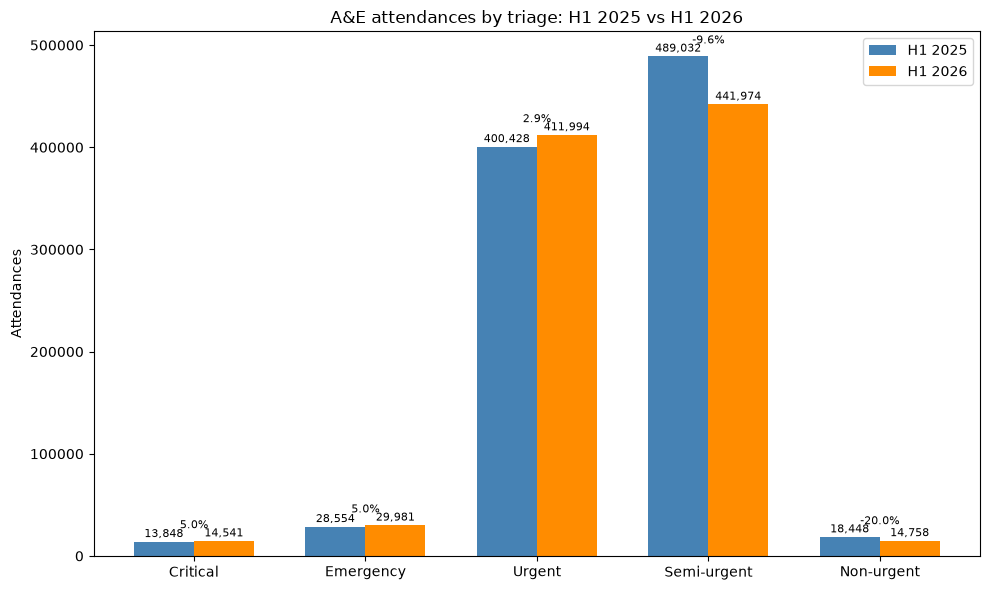

In [18]:
# Task 2 — write your own IPO prompt in the comments, then use Inline Chat
#
# Input:
#   A&E triage attendance data for H1 2025 and H1 2026, including triage names, attendance counts, and percentage change.
#
# Process:
#   I make this grouped bar chart aims to compare H1 2025 with H1 2026 attendances to easily see the numbers and percentage change. What I find is critical and emergency rise slightly, urgent is a little higher, semi-urgent falls sharply and non-urgent fall sharply. It shows that the lower-urgency groups are down while more serious groups are not falling.
#
# Output:
#   A grouped bar chart comparing H1 2025 and H1 2026 attendances by triage, with values and percentage changes clearly shown.
#
# YOUR CODE BELOW

import numpy as np
import matplotlib.pyplot as plt

# Ensure triage order is consistent
plot_df = df.sort_values('triage').reset_index(drop=True)

# Prepare x positions for grouped bars
x = np.arange(len(plot_df))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))

bars_2025 = ax.bar(
    x - width/2,
    plot_df['attend_h1_2025'],
    width=width,
    label='H1 2025',
    color='steelblue'
)

bars_2026 = ax.bar(
    x + width/2,
    plot_df['attend_h1_2026'],
    width=width,
    label='H1 2026',
    color='darkorange'
)

# Add axis labels and title
ax.set_title('A&E attendances by triage: H1 2025 vs H1 2026')
ax.set_ylabel('Attendances')
ax.set_xticks(x)
ax.set_xticklabels(plot_df['triage_name'])
ax.legend()

# Add actual attendance values above each bar
for bars in [bars_2025, bars_2026]:
    for bar in bars:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width()/2,
            height + 2000,
            f'{int(height):,}',
            ha='center',
            va='bottom',
            fontsize=8
        )

# Add percentage change labels near the group center
for i, pct in enumerate(plot_df['pct_change']):
    y_pos = max(plot_df['attend_h1_2025'].iloc[i], plot_df['attend_h1_2026'].iloc[i]) + 10000
    ax.text(
        x[i],
        y_pos,
        f'{pct:.1f}%',
        ha='center',
        va='bottom',
        fontsize=8,
        color='black'
    )

plt.tight_layout()
plt.show()


## Task 3 — Write-up

**Claim:** After fee reform, A&E improved — lower-urgency attendances fell; critical/emergency care stayed protected; urgent care became more efficient.

You may also cite: triage III within 30 min **81.4 → 88.5** (percentage); mean wait **23 → 20** min.

**3a** — Write **one supporting point** (cite a number) and **one gap** in the evidence.

**3b** — 2–4 sentences: how well is the claim supported by the published evidence (your table / chart, and any figures cited above)?


In [19]:
# Task 3
task3a = """
3a SUPPORT (1 point, cite a number):
The lower-urgency groups fell substantially after the reform: triage 4+5 combined attendances dropped from 507,480 to 456,732, a decline of 10.0%.

3a GAP (1 point):
The data are descriptive and do not prove the fee reform caused the change; other factors such as patient behaviour, care pathways, or seasonality could also explain the pattern.
"""

task3b = """
3b:
The claim is partly supported. The chart shows lower-urgency attendances falling while critical and emergency care stayed stable or rose, which matches the idea that less urgent A&E use declined while serious care was protected. The additional figures also support this: triage III within 30 minutes improved from 81.4% to 88.5%, and mean wait time fell from 23 to 20 minutes. However, the evidence is still limited because it is not causal and does not isolate the effect of fee reform from other changes in demand or service use.
"""

print(task3a)
print("---")
print(task3b)




3a SUPPORT (1 point, cite a number):
The lower-urgency groups fell substantially after the reform: triage 4+5 combined attendances dropped from 507,480 to 456,732, a decline of 10.0%.

3a GAP (1 point):
The data are descriptive and do not prove the fee reform caused the change; other factors such as patient behaviour, care pathways, or seasonality could also explain the pattern.

---

3b:
The claim is partly supported. The chart shows lower-urgency attendances falling while critical and emergency care stayed stable or rose, which matches the idea that less urgent A&E use declined while serious care was protected. The additional figures also support this: triage III within 30 minutes improved from 81.4% to 88.5%, and mean wait time fell from 23 to 20 minutes. However, the evidence is still limited because it is not causal and does not isolate the effect of fee reform from other changes in demand or service use.



## Submit

1. Save → Source Control → **Commit & Push**  
2. Moodle: paste your **GitHub URL**
